# 🔍 CESNET Network Anomaly Detection Pipeline

**Project**: AI-Augmented Observability System for ISP  
**Model**: LSTM Autoencoder (Unsupervised Anomaly Detection)  
**Dataset**: CESNET Time Series 24

---

## 📋 Pipeline Overview

1. **Load Data** - Read NPZ matrix with proper column labels
2. **Preprocess** - Log transform, normalize skewed features
3. **Create Windows** - Sliding windows for temporal patterns
4. **Train Model** - LSTM Autoencoder learns "normal" patterns
5. **Detect Anomalies** - High reconstruction error = anomaly
6. **Visualize** - Charts for presentation

## 1️⃣ Setup & Imports

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings
warnings.filterwarnings('ignore')

# Set style for beautiful plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

print("✅ Libraries loaded successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✅ Libraries loaded successfully!
PyTorch version: 2.0.1+cu118
CUDA available: True


## 2️⃣ Define Column Names (Reference for NPZ)

In [7]:
# Column names in order for your NPZ files
COLUMN_NAMES = [
    'id_time', 'n_flows', 'n_packets', 'n_bytes',
    'sum_n_dest_asn', 'average_n_dest_asn', 'std_n_dest_asn',
    'sum_n_dest_ports', 'average_n_dest_ports', 'std_n_dest_ports',
    'sum_n_dest_ip', 'average_n_dest_ip', 'std_n_dest_ip',
    'tcp_udp_ratio_packets', 'tcp_udp_ratio_bytes',
    'dir_ratio_packets', 'dir_ratio_bytes',
    'avg_duration', 'avg_ttl', 'ip_id'
]

# Feature indices (columns 1-18, excluding id_time and ip_id)
FEATURE_INDICES = list(range(1, 19))  # Columns 1 to 18
FEATURE_NAMES = COLUMN_NAMES[1:-1]

print(f"Total columns: {len(COLUMN_NAMES)}")
print(f"Feature columns for training: {len(FEATURE_NAMES)}")

Total columns: 20
Feature columns for training: 18


## 3️⃣ Load NPZ Data

In [8]:
# Path to your NPZ file
NPZ_PATH = r"C:\Users\bharg\OneDrive\Desktop\Major_Project\CESNET\institution_subnets\agg_1_day\npz\institutions_subnets_1day_merged_single.npz"

# Load the data
print("Loading NPZ file...")
npz_data = np.load(NPZ_PATH, allow_pickle=True)
print(f"Keys in NPZ: {list(npz_data.keys())}")

# Get the matrix
try:
    matrix = npz_data['full_matrix']
except KeyError:
    matrix = npz_data['arr_0']

# Convert to float32
matrix = matrix.astype(np.float32)

print(f"\n✅ Data loaded!")
print(f"Shape: {matrix.shape}")
print(f"Rows (samples): {matrix.shape[0]:,}")
print(f"Columns (features): {matrix.shape[1]}")

Loading NPZ file...
Keys in NPZ: ['full_matrix']

✅ Data loaded!
Shape: (150408, 20)
Rows (samples): 150,408
Columns (features): 20


## 4️⃣ Data Visualization (EDA) - Using NPZ Directly

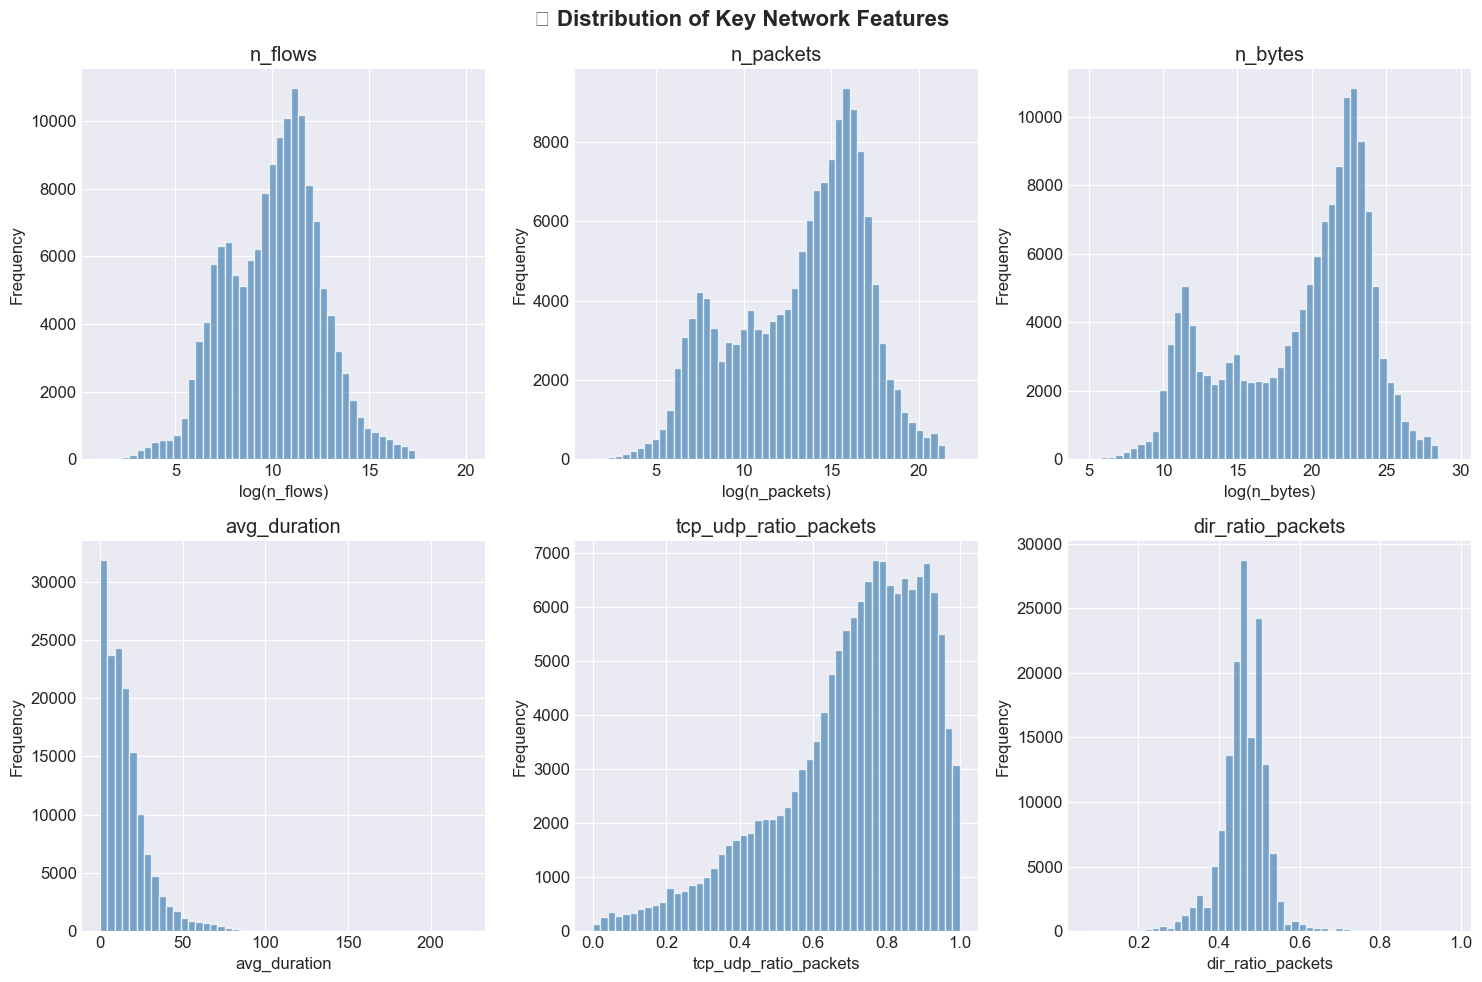

✅ Saved: visualization_1_distributions.png


In [9]:
# Visualization 1: Distribution of key features (using numpy array directly)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('📊 Distribution of Key Network Features', fontsize=16, fontweight='bold')

# Feature indices: n_flows=1, n_packets=2, n_bytes=3, avg_duration=17, tcp_udp_ratio_packets=13, dir_ratio_packets=15
features_to_plot = [(1, 'n_flows'), (2, 'n_packets'), (3, 'n_bytes'), 
                    (17, 'avg_duration'), (13, 'tcp_udp_ratio_packets'), (15, 'dir_ratio_packets')]

for idx, (col_idx, feature_name) in enumerate(features_to_plot):
    ax = axes[idx // 3, idx % 3]
    data = matrix[:, col_idx]
    
    # Use log scale for highly skewed features
    if feature_name in ['n_flows', 'n_packets', 'n_bytes']:
        data = np.log1p(data)
        ax.set_xlabel(f'log({feature_name})')
    else:
        ax.set_xlabel(feature_name)
    
    ax.hist(data, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{feature_name}')

plt.tight_layout()
plt.savefig('visualization_1_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: visualization_1_distributions.png")

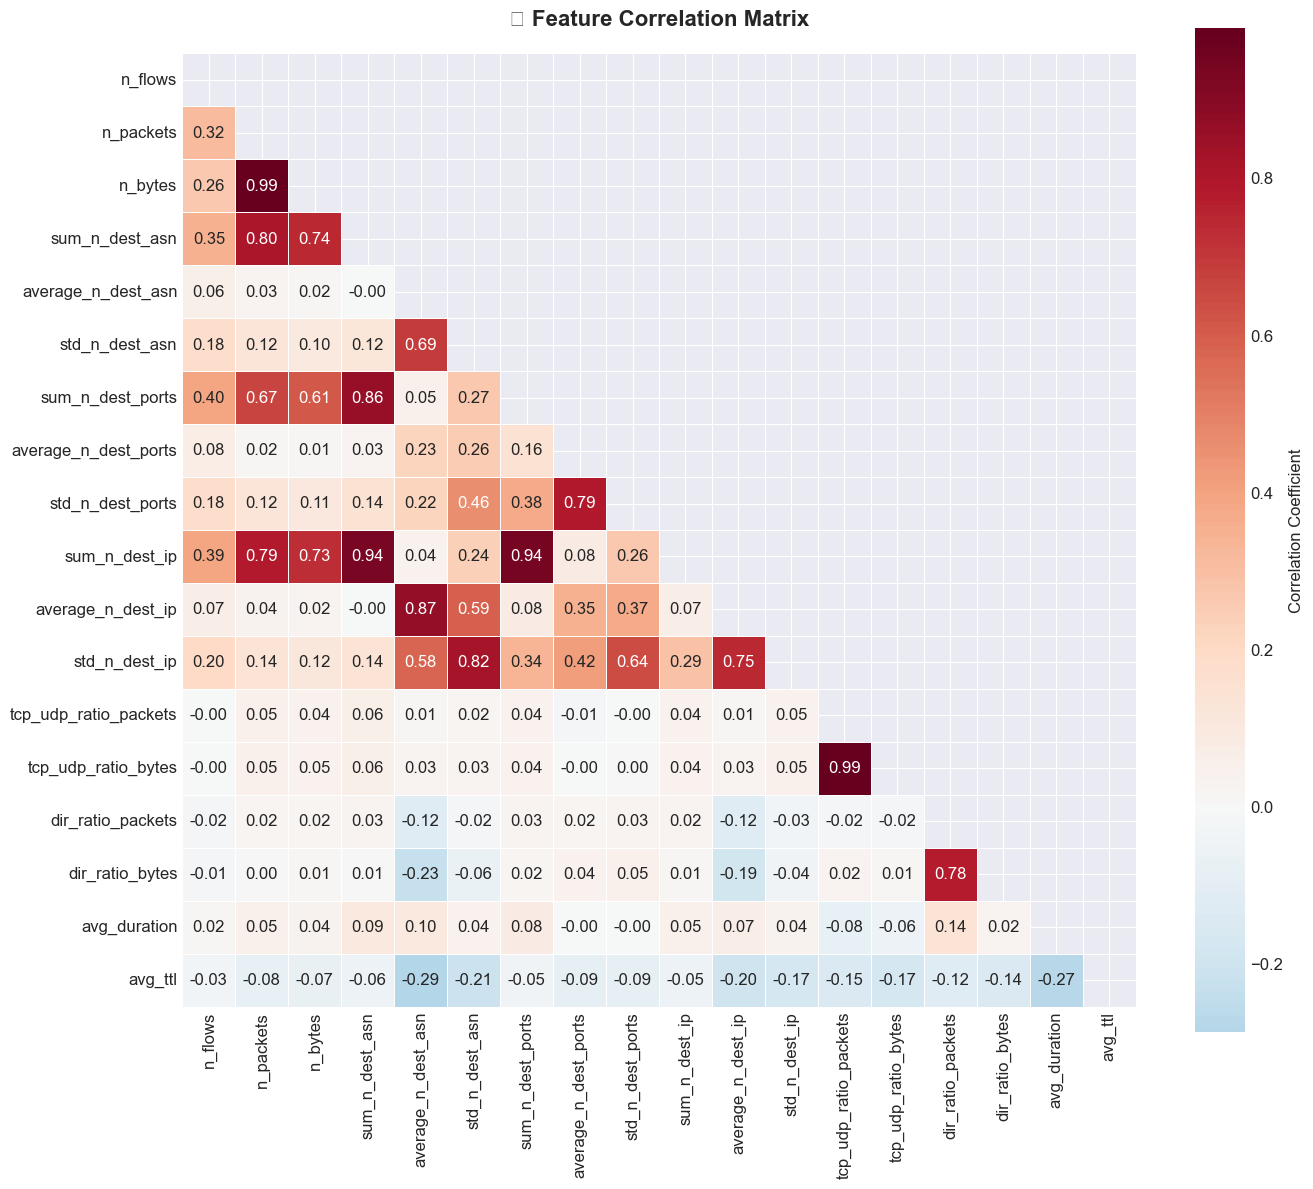

✅ Saved: visualization_2_correlation.png


In [10]:
# Visualization 2: Correlation Heatmap (using numpy)
plt.figure(figsize=(14, 12))

# Extract features and compute correlation
features_matrix = matrix[:, 1:-1]  # All features except id_time and ip_id
correlation_matrix = np.corrcoef(features_matrix.T)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0,
            fmt='.2f', square=True, linewidths=0.5,
            xticklabels=FEATURE_NAMES, yticklabels=FEATURE_NAMES,
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('🔗 Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('visualization_2_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: visualization_2_correlation.png")

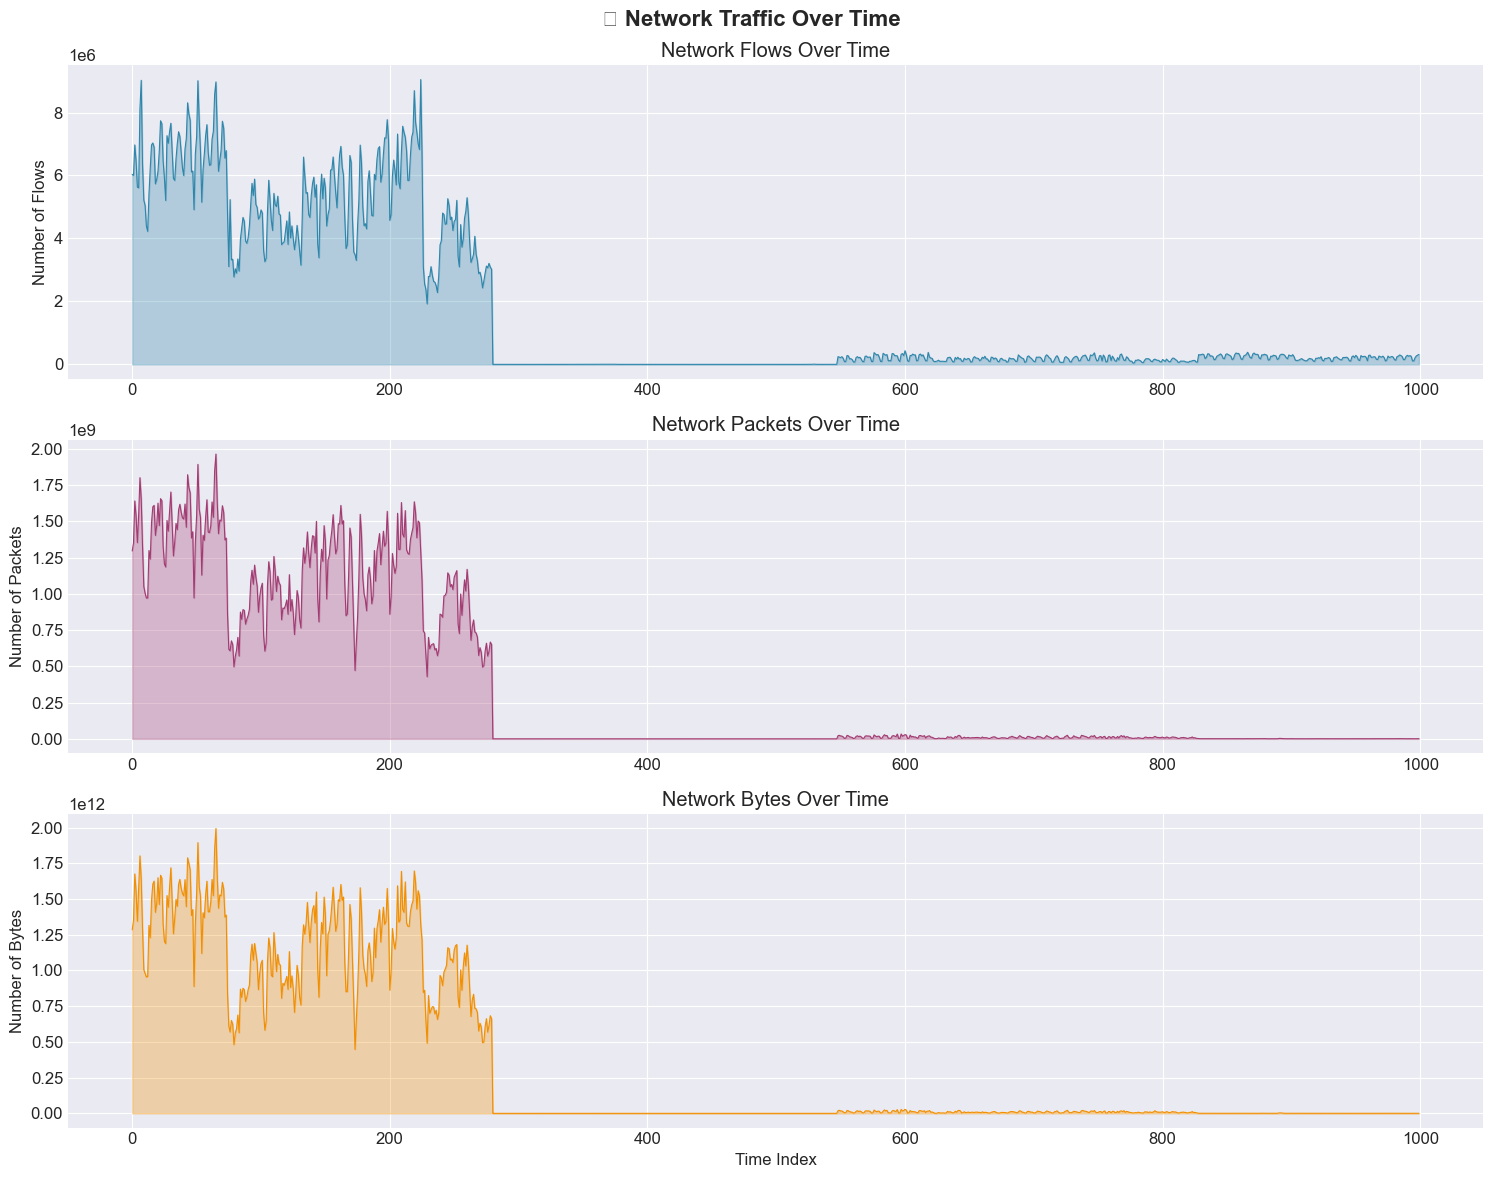

✅ Saved: visualization_3_timeseries.png


In [11]:
# Visualization 3: Time Series of Network Traffic (using numpy)
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
fig.suptitle('📈 Network Traffic Over Time', fontsize=16, fontweight='bold')

# Plot first 1000 samples
n_samples = min(1000, matrix.shape[0])
time_indices = np.arange(n_samples)

# n_flows (column 1)
axes[0].plot(time_indices, matrix[:n_samples, 1], color='#2E86AB', linewidth=0.8)
axes[0].fill_between(time_indices, matrix[:n_samples, 1], alpha=0.3, color='#2E86AB')
axes[0].set_ylabel('Number of Flows')
axes[0].set_title('Network Flows Over Time')

# n_packets (column 2)
axes[1].plot(time_indices, matrix[:n_samples, 2], color='#A23B72', linewidth=0.8)
axes[1].fill_between(time_indices, matrix[:n_samples, 2], alpha=0.3, color='#A23B72')
axes[1].set_ylabel('Number of Packets')
axes[1].set_title('Network Packets Over Time')

# n_bytes (column 3)
axes[2].plot(time_indices, matrix[:n_samples, 3], color='#F18F01', linewidth=0.8)
axes[2].fill_between(time_indices, matrix[:n_samples, 3], alpha=0.3, color='#F18F01')
axes[2].set_ylabel('Number of Bytes')
axes[2].set_xlabel('Time Index')
axes[2].set_title('Network Bytes Over Time')

plt.tight_layout()
plt.savefig('visualization_3_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: visualization_3_timeseries.png")

## 5️⃣ Data Preprocessing

In [12]:
# Extract features (drop id columns) - columns 1 to 18
X = matrix[:, 1:-1].astype(np.float32)

# Handle NaN and Inf values
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Feature matrix shape: {X.shape}")
print(f"Any NaN values: {np.isnan(X).any()}")
print(f"Any Inf values: {np.isinf(X).any()}")

Feature matrix shape: (150408, 18)
Any NaN values: False
Any Inf values: False


In [13]:
# Log transform highly skewed features (n_flows, n_packets, n_bytes)
# These are at indices 0, 1, 2 in our feature matrix
skewed_indices = [0, 1, 2]  # n_flows, n_packets, n_bytes

X_transformed = X.copy()
for idx in skewed_indices:
    X_transformed[:, idx] = np.log1p(X[:, idx])

print("\n✅ Log transformation applied to: n_flows, n_packets, n_bytes")


✅ Log transformation applied to: n_flows, n_packets, n_bytes


In [14]:
# Normalize features to [0, 1] range
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X_transformed)

print(f"\n✅ Features normalized to [0, 1]")
print(f"Min values: {X_normalized.min(axis=0).round(3)}")
print(f"Max values: {X_normalized.max(axis=0).round(3)}")


✅ Features normalized to [0, 1]
Min values: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Max values: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 6️⃣ Create Sliding Windows for Temporal Patterns

In [15]:
def create_sliding_windows(data, window_size=10):
    """Create sliding windows for time series data."""
    windows = []
    for i in range(len(data) - window_size + 1):
        windows.append(data[i:i + window_size])
    return np.array(windows)

WINDOW_SIZE = 10
X_windows = create_sliding_windows(X_normalized, WINDOW_SIZE)

print(f"\n✅ Sliding windows created!")
print(f"Original shape: {X_normalized.shape}")
print(f"Windows shape: {X_windows.shape}")
print(f"  - {X_windows.shape[0]} samples")
print(f"  - {X_windows.shape[1]} time steps per sample")
print(f"  - {X_windows.shape[2]} features")


✅ Sliding windows created!
Original shape: (150408, 18)
Windows shape: (150399, 10, 18)
  - 150399 samples
  - 10 time steps per sample
  - 18 features


## 7️⃣ Define LSTM Autoencoder Model

In [16]:
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, n_layers=2, dropout=0.2):
        super(LSTMAutoencoder, self).__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, n_layers, batch_first=True, 
                               dropout=dropout if n_layers > 1 else 0)
        self.decoder = nn.LSTM(hidden_dim, hidden_dim, n_layers, batch_first=True,
                               dropout=dropout if n_layers > 1 else 0)
        self.output_layer = nn.Linear(hidden_dim, input_dim)
        
    def forward(self, x):
        batch_size, seq_len, _ = x.size()
        _, (hidden, cell) = self.encoder(x)
        decoder_input = hidden[-1].unsqueeze(1).repeat(1, seq_len, 1)
        decoded, _ = self.decoder(decoder_input, (hidden, cell))
        return self.output_layer(decoded)

print("✅ LSTM Autoencoder model defined!")

✅ LSTM Autoencoder model defined!


## 8️⃣ Train the Model

In [22]:
# Setup with Train/Validation Split
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create train/validation split (80/20)
X_tensor = torch.FloatTensor(X_windows)
train_size = int(0.8 * len(X_tensor))
val_size = len(X_tensor) - train_size
train_data, val_data = torch.utils.data.random_split(TensorDataset(X_tensor, X_tensor), [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)

input_dim = X_windows.shape[2]
model = LSTMAutoencoder(input_dim=input_dim, hidden_dim=64, n_layers=2, dropout=0.3).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f"\n✅ Model initialized!")
print(f"Training samples: {train_size:,}")
print(f"Validation samples: {val_size:,}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda

✅ Model initialized!
Training samples: 120,319
Validation samples: 30,080
Total parameters: 122,514


In [23]:
# Training loop with validation
EPOCHS = 30
train_losses = []
val_losses = []

print("\n🚀 Starting training...\n")

for epoch in range(EPOCHS):
    # Training phase
    model.train()
    epoch_train_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()
    
    # Validation phase
    model.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            output = model(batch_x)
            loss = criterion(output, batch_y)
            epoch_val_loss += loss.item()
    
    avg_train_loss = epoch_train_loss / len(train_loader)
    avg_val_loss = epoch_val_loss / len(val_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}] - Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}")

print(f"\n✅ Training complete!")
print(f"Final Train Loss: {train_losses[-1]:.6f}")
print(f"Final Val Loss: {val_losses[-1]:.6f}")


🚀 Starting training...

Epoch [5/30] - Train Loss: 0.000388, Val Loss: 0.000334
Epoch [10/30] - Train Loss: 0.000253, Val Loss: 0.000209
Epoch [15/30] - Train Loss: 0.000186, Val Loss: 0.000147
Epoch [20/30] - Train Loss: 0.000140, Val Loss: 0.000110
Epoch [25/30] - Train Loss: 0.000119, Val Loss: 0.000087
Epoch [30/30] - Train Loss: 0.000104, Val Loss: 0.000077

✅ Training complete!
Final Train Loss: 0.000104
Final Val Loss: 0.000077


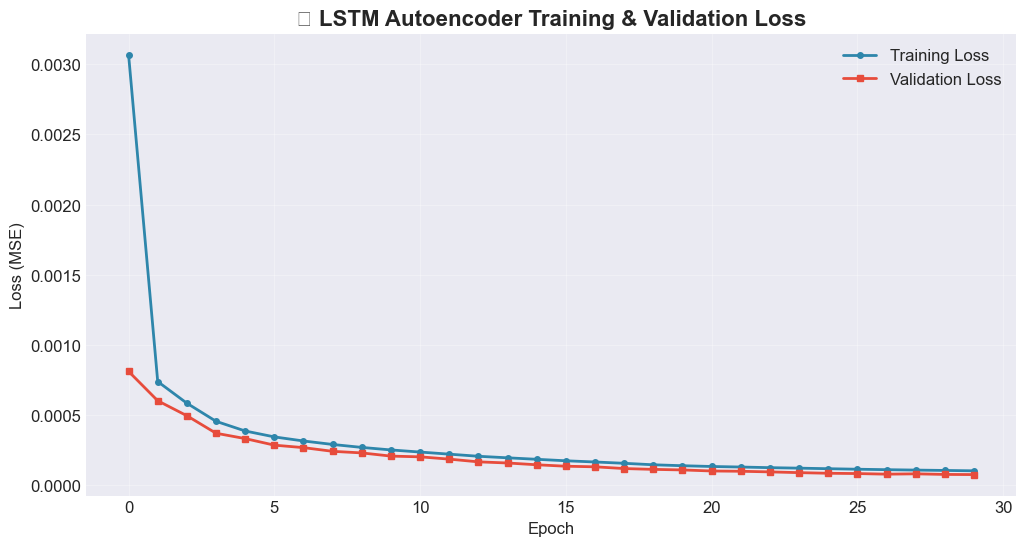

✅ Saved: visualization_4_training_loss.png


In [24]:
# Visualization 4: Combined Training and Validation Loss Curve
plt.figure(figsize=(12, 6))
plt.plot(train_losses, color='#2E86AB', linewidth=2, marker='o', markersize=4, label='Training Loss')
plt.plot(val_losses, color='#E74C3C', linewidth=2, marker='s', markersize=4, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('📉 LSTM Autoencoder Training & Validation Loss', fontsize=16, fontweight='bold')
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, alpha=0.3)
plt.savefig('visualization_4_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: visualization_4_training_loss.png")

## 9️⃣ Calculate Anomaly Scores

In [25]:
# Calculate anomaly scores in batches to avoid OOM Error
model.eval()
BATCH_SIZE = 256  # Smaller batch size for inference

# Create dataloader for full dataset
full_dataset = TensorDataset(X_tensor, X_tensor)
full_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False)

all_errors = []
print("Calculating anomaly scores in batches...")

with torch.no_grad():
    for batch_idx, (batch_x, batch_y) in enumerate(full_loader):
        batch_x = batch_x.to(device)
        reconstructed = model(batch_x)
        batch_errors = torch.mean((batch_x - reconstructed) ** 2, dim=(1, 2))
        all_errors.append(batch_errors.cpu())
        
        if (batch_idx + 1) % 100 == 0:
            print(f"  Processed batch {batch_idx+1}/{len(full_loader)}")

anomaly_scores = torch.cat(all_errors).numpy()

print(f"\n✅ Anomaly scores calculated!")
print(f"Scores shape: {anomaly_scores.shape}")
print(f"Min score: {anomaly_scores.min():.6f}")
print(f"Max score: {anomaly_scores.max():.6f}")
print(f"Mean score: {anomaly_scores.mean():.6f}")

Calculating anomaly scores in batches...
  Processed batch 100/588
  Processed batch 200/588
  Processed batch 300/588
  Processed batch 400/588
  Processed batch 500/588

✅ Anomaly scores calculated!
Scores shape: (150399,)
Min score: 0.000008
Max score: 0.003701
Mean score: 0.000075


In [26]:
# Set threshold (top 5% as anomalies)
PERCENTILE = 95
threshold = np.percentile(anomaly_scores, PERCENTILE)
is_anomaly = anomaly_scores > threshold

print(f"\n🎯 Anomaly Detection Results:")
print(f"="*40)
print(f"Threshold (P{PERCENTILE}): {threshold:.6f}")
print(f"Total samples: {len(anomaly_scores):,}")
print(f"Normal samples: {(~is_anomaly).sum():,} ({100*(~is_anomaly).mean():.1f}%)")
print(f"Anomalies detected: {is_anomaly.sum():,} ({100*is_anomaly.mean():.1f}%)")


🎯 Anomaly Detection Results:
Threshold (P95): 0.000230
Total samples: 150,399
Normal samples: 142,879 (95.0%)
Anomalies detected: 7,520 (5.0%)


## 🔟 Visualize Anomaly Detection Results

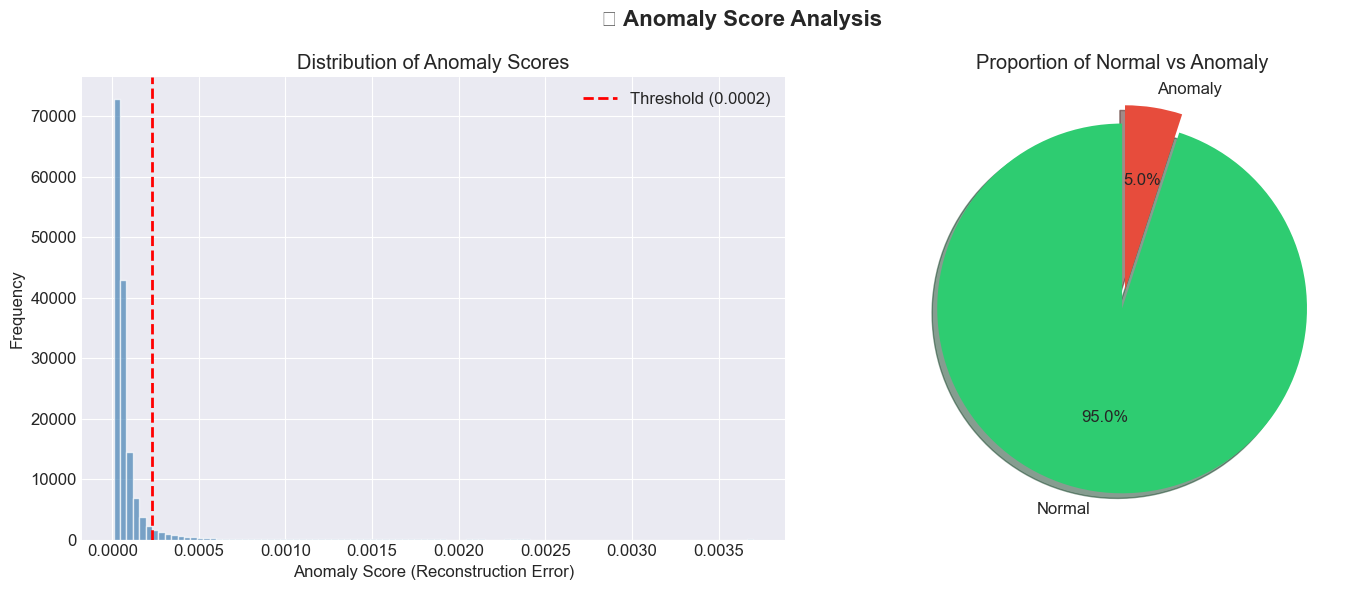

✅ Saved: visualization_5_anomaly_distribution.png


In [27]:
# Visualization 5: Anomaly Score Distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('🔍 Anomaly Score Analysis', fontsize=16, fontweight='bold')

axes[0].hist(anomaly_scores, bins=100, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.4f})')
axes[0].set_xlabel('Anomaly Score (Reconstruction Error)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Anomaly Scores')
axes[0].legend()

sizes = [(~is_anomaly).sum(), is_anomaly.sum()]
axes[1].pie(sizes, explode=(0, 0.1), labels=['Normal', 'Anomaly'], colors=['#2ECC71', '#E74C3C'],
            autopct='%1.1f%%', shadow=True, startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Proportion of Normal vs Anomaly')

plt.tight_layout()
plt.savefig('visualization_5_anomaly_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: visualization_5_anomaly_distribution.png")

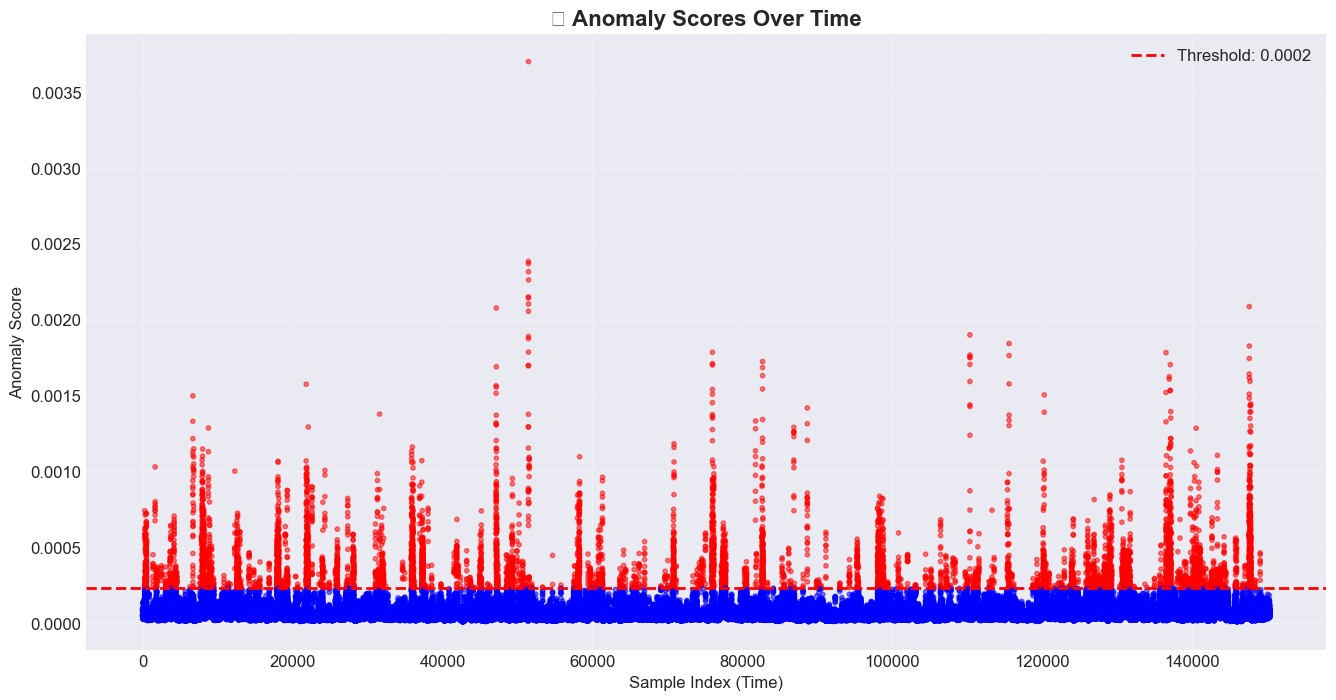

✅ Saved: visualization_6_anomaly_timeline.png


In [28]:
# Visualization 6: Anomaly Scores Over Time
plt.figure(figsize=(16, 8))
colors = ['red' if a else 'blue' for a in is_anomaly]
plt.scatter(range(len(anomaly_scores)), anomaly_scores, c=colors, alpha=0.5, s=10)
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.4f}')
plt.xlabel('Sample Index (Time)')
plt.ylabel('Anomaly Score')
plt.title('⏰ Anomaly Scores Over Time', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('visualization_6_anomaly_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: visualization_6_anomaly_timeline.png")

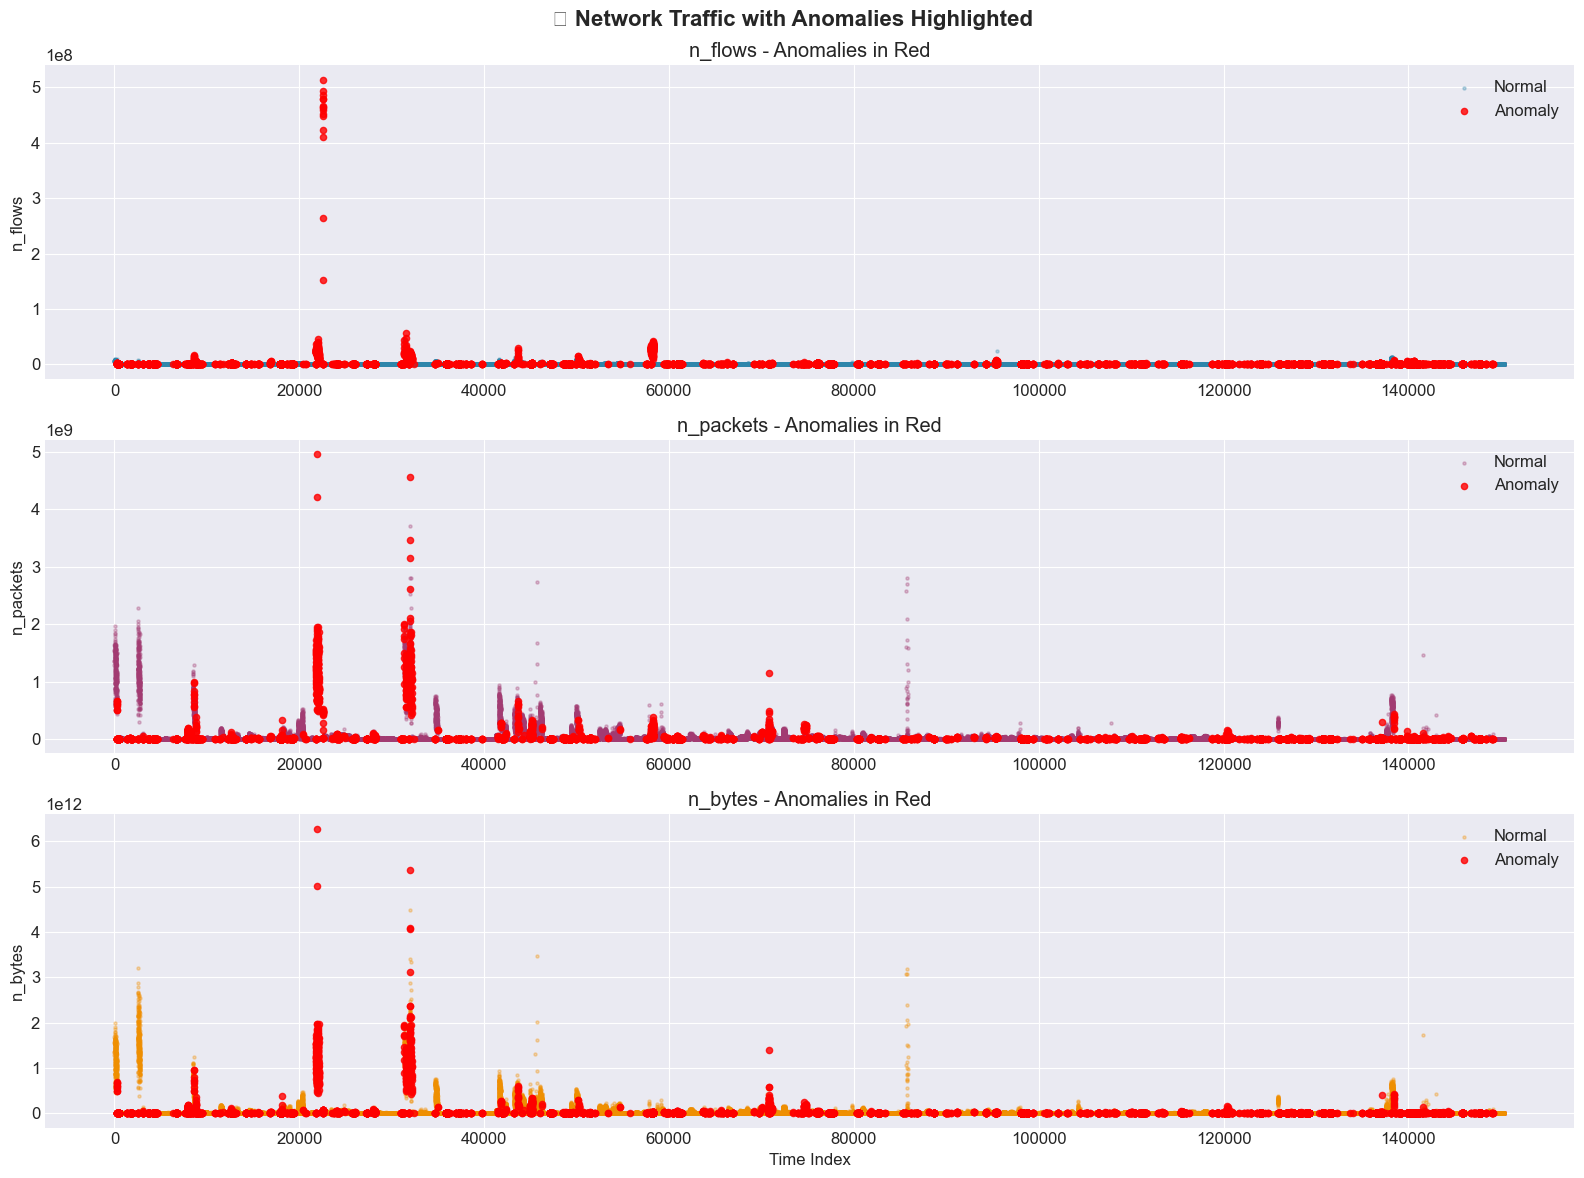

✅ Saved: visualization_7_traffic_anomalies.png


In [29]:
# Visualization 7: Network Traffic with Anomalies Highlighted (using numpy)
fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('🚨 Network Traffic with Anomalies Highlighted', fontsize=16, fontweight='bold')

# Use original matrix (first len(anomaly_scores) rows)
n_samples = len(anomaly_scores)
features_info = [(1, 'n_flows', '#2E86AB'), (2, 'n_packets', '#A23B72'), (3, 'n_bytes', '#F18F01')]

for idx, (col_idx, feature_name, color) in enumerate(features_info):
    ax = axes[idx]
    data = matrix[:n_samples, col_idx]
    
    # Normal points
    normal_mask = ~is_anomaly
    ax.scatter(np.where(normal_mask)[0], data[normal_mask], c=color, alpha=0.3, s=5, label='Normal')
    
    # Anomaly points
    ax.scatter(np.where(is_anomaly)[0], data[is_anomaly], c='red', alpha=0.8, s=20, label='Anomaly')
    
    ax.set_ylabel(feature_name)
    ax.legend(loc='upper right')
    ax.set_title(f'{feature_name} - Anomalies in Red')

axes[2].set_xlabel('Time Index')
plt.tight_layout()
plt.savefig('visualization_7_traffic_anomalies.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: visualization_7_traffic_anomalies.png")

## 1️⃣1️⃣ Save Results

In [30]:
# Create DataFrame for saving (only now, for export)
n_samples = len(anomaly_scores)
df = pd.DataFrame(matrix[:n_samples], columns=COLUMN_NAMES)
df['anomaly_score'] = anomaly_scores
df['is_anomaly'] = is_anomaly

# Save to CSV
df.to_csv('anomaly_detection_results.csv', index=False)
print("✅ Saved: anomaly_detection_results.csv")

# Save model
torch.save({'model_state_dict': model.state_dict(), 'threshold': threshold,
            'scaler_min': scaler.data_min_, 'scaler_max': scaler.data_max_}, 'lstm_autoencoder_model.pth')
print("✅ Saved: lstm_autoencoder_model.pth")

✅ Saved: anomaly_detection_results.csv
✅ Saved: lstm_autoencoder_model.pth


In [31]:
# Show sample results
print("\n📊 Sample Results (First 10 rows):")
display_cols = ['id_time', 'n_flows', 'n_packets', 'n_bytes', 'anomaly_score', 'is_anomaly']
print(df[display_cols].head(10))

print("\n🚨 Sample Detected Anomalies:")
print(df[df['is_anomaly']][display_cols].head(10))


📊 Sample Results (First 10 rows):
   id_time    n_flows     n_packets       n_bytes  anomaly_score  is_anomaly
0      0.0  6037276.0  1.296003e+09  1.283605e+12       0.000085       False
1      1.0  6003202.0  1.352725e+09  1.352567e+12       0.000092       False
2      2.0  6970395.0  1.641867e+09  1.675324e+12       0.000097       False
3      3.0  6456615.0  1.538404e+09  1.553394e+12       0.000086       False
4      4.0  5630980.0  1.353925e+09  1.343859e+12       0.000076       False
5      5.0  5608853.0  1.545271e+09  1.563984e+12       0.000084       False
6      6.0  8109116.0  1.802092e+09  1.801722e+12       0.000084       False
7      7.0  9022666.0  1.651514e+09  1.634615e+12       0.000085       False
8      8.0  6348357.0  1.331712e+09  1.293487e+12       0.000056       False
9      9.0  5218956.0  1.051143e+09  1.005776e+12       0.000053       False

🚨 Sample Detected Anomalies:
     id_time    n_flows    n_packets       n_bytes  anomaly_score  is_anomaly
272    272

## 1️⃣2️⃣ Summary for Presentation

In [32]:
print("\n" + "="*70)
print("           📊 ANOMALY DETECTION SUMMARY FOR PRESENTATION")
print("="*70)
print(f"""
🎯 PROJECT: AI-Augmented Observability System for ISP
📊 DATASET: CESNET Time Series 24 (Network Traffic)
🤖 MODEL: LSTM Autoencoder (Unsupervised)

📈 DATA STATISTICS:
   • Total samples analyzed: {len(anomaly_scores):,}
   • Features used: {len(FEATURE_NAMES)}
   • Time window size: {WINDOW_SIZE} steps

🔍 DETECTION RESULTS:
   • Anomaly threshold (P{PERCENTILE}): {threshold:.6f}
   • Normal traffic: {(~is_anomaly).sum():,} ({100*(~is_anomaly).mean():.1f}%)
   • Anomalies detected: {is_anomaly.sum():,} ({100*is_anomaly.mean():.1f}%)

📁 OUTPUT FILES:
   • anomaly_detection_results.csv (For Grafana)
   • lstm_autoencoder_model.pth (Trained model)
   • 7 visualization images (For presentation)

✅ KEY TAKEAWAYS:
   1. Model learns "normal" network patterns
   2. High reconstruction error = anomaly
   3. Top {100-PERCENTILE}% unusual patterns flagged as anomalies
   4. Ready for Grafana dashboard integration
""")
print("="*70)
print("\n🎉 PIPELINE COMPLETE!")


           📊 ANOMALY DETECTION SUMMARY FOR PRESENTATION

🎯 PROJECT: AI-Augmented Observability System for ISP
📊 DATASET: CESNET Time Series 24 (Network Traffic)
🤖 MODEL: LSTM Autoencoder (Unsupervised)

📈 DATA STATISTICS:
   • Total samples analyzed: 150,399
   • Features used: 18
   • Time window size: 10 steps

🔍 DETECTION RESULTS:
   • Anomaly threshold (P95): 0.000230
   • Normal traffic: 142,879 (95.0%)
   • Anomalies detected: 7,520 (5.0%)

📁 OUTPUT FILES:
   • anomaly_detection_results.csv (For Grafana)
   • lstm_autoencoder_model.pth (Trained model)
   • 7 visualization images (For presentation)

✅ KEY TAKEAWAYS:
   1. Model learns "normal" network patterns
   2. High reconstruction error = anomaly
   3. Top 5% unusual patterns flagged as anomalies
   4. Ready for Grafana dashboard integration


🎉 PIPELINE COMPLETE!
